In [ ]:
from google.colab import files
files.upload()  # Upload the kaggle.json file

Saving insurance.csv to insurance.csv


{'insurance.csv': b'age,sex,bmi,children,smoker,region,charges\r\n19,female,27.9,0,yes,southwest,16884.924\r\n18,male,33.77,1,no,southeast,1725.5523\r\n28,male,33,3,no,southeast,4449.462\r\n33,male,22.705,0,no,northwest,21984.47061\r\n32,male,28.88,0,no,northwest,3866.8552\r\n31,female,25.74,0,no,southeast,3756.6216\r\n46,female,33.44,1,no,southeast,8240.5896\r\n37,female,27.74,3,no,northwest,7281.5056\r\n37,male,29.83,2,no,northeast,6406.4107\r\n60,female,25.84,0,no,northwest,28923.13692\r\n25,male,26.22,0,no,northeast,2721.3208\r\n62,female,26.29,0,yes,southeast,27808.7251\r\n23,male,34.4,0,no,southwest,1826.843\r\n56,female,39.82,0,no,southeast,11090.7178\r\n27,male,42.13,0,yes,southeast,39611.7577\r\n19,male,24.6,1,no,southwest,1837.237\r\n52,female,30.78,1,no,northeast,10797.3362\r\n23,male,23.845,0,no,northeast,2395.17155\r\n56,male,40.3,0,no,southwest,10602.385\r\n30,male,35.3,0,yes,southwest,36837.467\r\n60,female,36.005,0,no,northeast,13228.84695\r\n30,female,32.4,1,no,southwe

In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('insurance.csv')

# Show first 5 rows
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Convert categorical to numerical
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])  # Male:1, Female:0
df['smoker'] = le.fit_transform(df['smoker'])  # Yes:1, No:0

# One-hot encode region
ct = ColumnTransformer(
    [('one_hot', OneHotEncoder(), ['region'])],
    remainder='passthrough'
)
X = ct.fit_transform(df.drop('charges', axis=1))
y = df['charges']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Linear Regression:")
print(f"MAE: ${mean_absolute_error(y_test, y_pred_lr):.2f}")
print(f"R² Score: {r2_score(y_test, y_pred_lr):.4f}")

Linear Regression:
MAE: $4181.19
R² Score: 0.7836


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Linear Regression:")
print(f"MAE: ${mean_absolute_error(y_test, y_pred_lr):.2f}")
print(f"R² Score: {r2_score(y_test, y_pred_lr):.4f}")

Linear Regression:
MAE: $4181.19
R² Score: 0.7836


In [ ]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("\nDecision Tree:")
print(f"MAE: ${mean_absolute_error(y_test, y_pred_dt):.2f}")
print(f"R² Score: {r2_score(y_test, y_pred_dt):.4f}")


Decision Tree:
MAE: $2911.16
R² Score: 0.8334


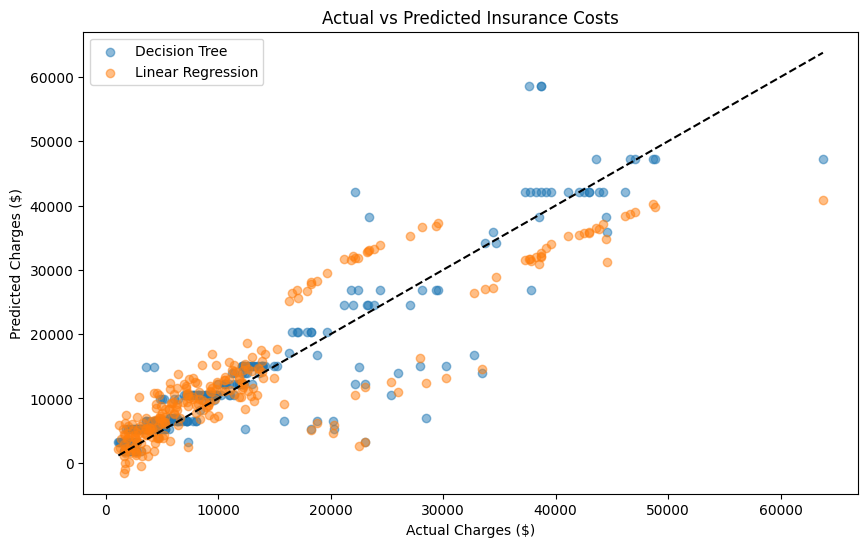

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred_dt, alpha=0.5, label='Decision Tree')
plt.scatter(y_test, y_pred_lr, alpha=0.5, label='Linear Regression')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
plt.xlabel('Actual Charges ($)')
plt.ylabel('Predicted Charges ($)')
plt.title('Actual vs Predicted Insurance Costs')
plt.legend()
plt.show()

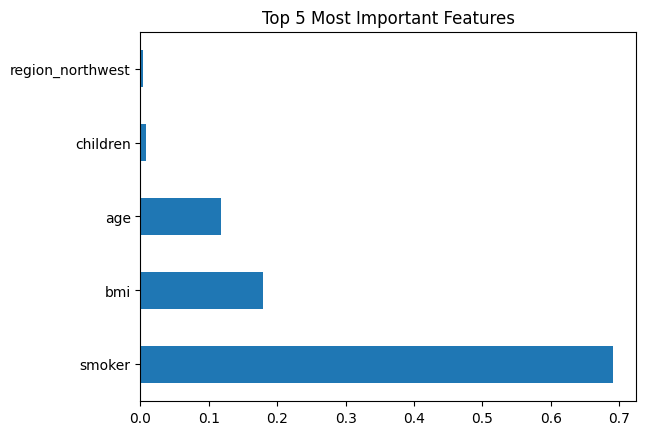

In [ ]:
# Get feature names after one-hot encoding
feature_names = list(ct.named_transformers_['one_hot'].get_feature_names_out(['region'])) + \
               ['age', 'sex', 'bmi', 'children', 'smoker']

feat_importances = pd.Series(dt.feature_importances_, index=feature_names)
feat_importances.nlargest(5).plot(kind='barh')
plt.title('Top 5 Most Important Features')
plt.show()

In [ ]:
import joblib

# Save the decision tree model
joblib.dump(dt, 'insurance_model.pkl')

# Download the model file to your computer
from google.colab import files
files.download('insurance_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
def predict_insurance_cost(age, sex, bmi, children, smoker, region):
    """
    sex: 0 (female) or 1 (male)
    smoker: 0 (no) or 1 (yes)
    region: northeast, northwest, southeast, southwest
    """
    # Create input array
    input_data = pd.DataFrame({
        'age': [age],
        'sex': [sex],
        'bmi': [bmi],
        'children': [children],
        'smoker': [smoker],
        'region': [region]
    })

    # Preprocess the input
    processed_data = ct.transform(input_data)

    # Make prediction
    prediction = dt.predict(processed_data)[0]

    return f"Predicted Insurance Cost: ${prediction:.2f}"

# Example usage
print(predict_insurance_cost(25, 1, 28.5, 0, 1, 'southeast'))

Predicted Insurance Cost: $20323.20


R² Score: 0.87
Mean Absolute Error: 2501.34


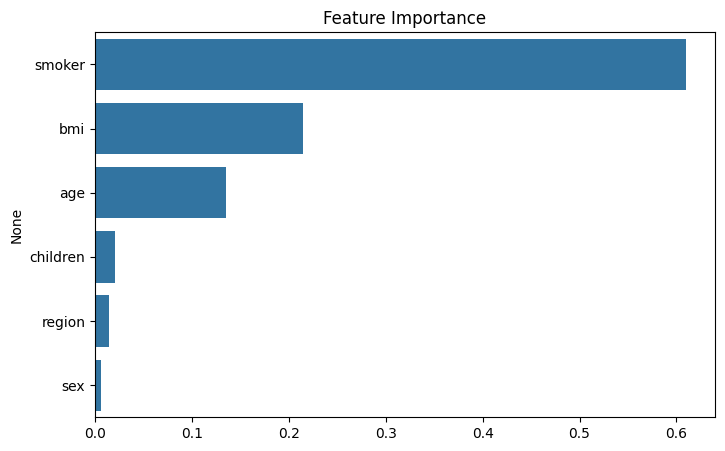

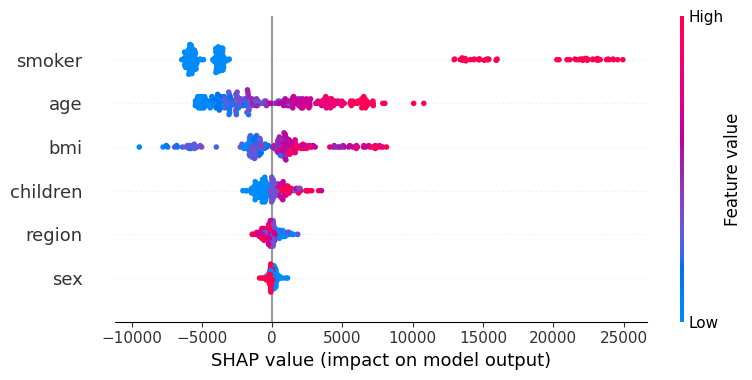

Predicted Insurance Cost for sample: $6462.96


In [3]:
# 📚 Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder

!pip install shap
import shap
shap.initjs()

# 🏥 Load dataset
data = pd.read_csv('insurance.csv')

# 🔤 Label encode categorical columns
le = LabelEncoder()
for col in ['sex', 'smoker', 'region']:
    data[col] = le.fit_transform(data[col])

# 🧹 Split features and target
X = data.drop('charges', axis=1)
y = data['charges']

# 🛠 Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 🌲 Train Random Forest model
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

# 📈 Make predictions
y_pred = model.predict(X_test)

# 📊 Evaluate
print(f"R² Score: {r2_score(y_test, y_pred):.2f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred):.2f}")

# 📌 Feature Importance
importances = model.feature_importances_
feat_importance = pd.Series(importances, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=feat_importance.values, y=feat_importance.index)
plt.title('Feature Importance')
plt.show()

# 🔍 Explain Predictions with SHAP
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Plot summary
shap.summary_plot(shap_values, X_test)

# ✅ Predicting a new sample
sample = pd.DataFrame({
    'age': [35],
    'sex': [1],         # 1 = Male after encoding
    'bmi': [28.0],
    'children': [2],
    'smoker': [0],      # 0 = Non-smoker
    'region': [2]       # Example: Southwest
})
sample_pred = model.predict(sample)
print(f"Predicted Insurance Cost for sample: ${sample_pred[0]:.2f}")
